# S2 Human Study Results
Reads all `evaluation/humans/by_participant/*.json`, filters to participants with
`>= MIN_ANSWERS` answers, then restricts to the **intersection** of question IDs
across all qualifying participants.

In [15]:
!python /home/david/Desktop/yuna/HPA/evaluation/humans/export_participants.py --delete-source-files

Loaded participant records: 0
Unique participant codes: 0
Duplicate participant codes: 0
Wrote files: 0
Deleted source files: 0


In [ ]:
import re
import json, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from collections import defaultdict

BASE = Path('/home/david/Desktop/yuna/HPA')
sys.path.insert(0, str(BASE / 'analysis'))  # must come before utils imports

from utils.normalize_korean import normalize_korean_answer
from utils.vqa import VQAAnswerMapper, vqa_accuracy
from utils.constants import VARIANT_ORDER, VARIANT_LABELS, VARIANT_COLORS
mapper = VQAAnswerMapper()

sns.set_theme(style='whitegrid', font_scale=1.1)

import re as _re
from utils.load_session import clean_answer as _clean_answer 
import importlib, utils.load_session
importlib.reload(utils.load_session)
from utils.load_session import backfill_question_text

backfill_question_text(BASE, s2_version='s2_v4')

In [38]:
# ── Load human data (participants → translate → flatten → intersect) ──────────
from utils.load_session import load_human_data, check_translation_coverage

MIN_ANSWERS = 350
participants, common_qids, df, mapper = load_human_data(BASE, min_answers=MIN_ANSWERS)
check_translation_coverage(df, BASE / 'analysis/utils/kr_answer_map.json')

print(f'\ndf shape: {df.shape}')
df.head(3)[['participant','variant','answer_kr','answer_en','gt','accuracy']]

Qualifying participants (>= 350 answers): 13
  0X4B4L3T  answers=402  qids=134
  BEK0Y4W3  answers=402  qids=134
  BTTWUQG4  answers=402  qids=134
  DYAN3RF8  answers=402  qids=134
  FXDCPFHM  answers=402  qids=134
  HGIX7HE0  answers=402  qids=134
  IV0PL083  answers=402  qids=134
  J0OU3FTE  answers=372  qids=124
  JOJCF28V  answers=372  qids=124
  OBRNN1JM  answers=402  qids=134
  ON7P7X1E  answers=372  qids=124
  TRFMV4H2  answers=372  qids=124
  Y2IBXIJX  answers=372  qids=124
Raw Korean strings      : 1276
Already translated      : 1276
Unique canonicals to translate: 0

✓ All Korean answers already mapped.
   Loading VQA annotations from /home/david/Desktop/yuna/data/v2_mscoco_val2014_annotations.json...
   ✓ Loaded 214354 VQA annotations

Common question_ids: 124
Rows: 4836 | questions: 124 | participants: 13
Answers still in Korean (scored 0): 0 / 4836 (0.0%)
Total     : 4836
Translated: 4836  (100.0%)
Untranslated: 0  (0.0%)
✓ All answers translated.

df shape: (4836, 19)


,participant,variant,answer_kr,answer_en,gt,accuracy
0,JOJCF28V,A,2,2,"[56, 18, 20, 50, 15, 35, herd, several, lot, 19]",0.000000
1,JOJCF28V,C,1,1,"[2, 2, 1, 2, 2, 2, 2, 1, 2, 2]",0.666667
2,JOJCF28V,C,no,no,"[no, no, no, no, no, no, no, no, no, no]",1.000000


In [39]:
# ── Load model results (inst_blind) ──────────────────────────────────────────
from utils.load_session import load_model_results, VARIANT_ORDER

q_ids = set(df['question_id'].tolist())
model_q_acc, MODEL_TYPE, MODELS, ALL_MODELS = load_model_results(BASE, q_ids)

   Loading VQA annotations from /home/david/Desktop/yuna/data/v2_mscoco_val2014_annotations.json...
   ✓ Loaded 214354 VQA annotations
Loaded vqa_1k_control_inst_blind for: ['Qwen3-VL-8B', 'LLaVA-1.5-7B', 'LLaVA-Mistral', 'LLaVA-Vicuna', 'InternVL-1B', 'InternVL-2B', 'InternVL-8B', 'LLaVA-1.5 (LM)', 'LLaVA-Mistral (LM)', 'LLaVA-Vicuna (LM)', 'Qwen3-8B']
  [VLM         ] Qwen3-VL-8B: 123 questions, mean C = 0.491
  [VLM         ] LLaVA-1.5-7B: 124 questions, mean C = 0.508
  [VLM         ] LLaVA-Mistral: 124 questions, mean C = 0.551
  [VLM         ] LLaVA-Vicuna: 124 questions, mean C = 0.532
  [VLM         ] InternVL-1B: 124 questions, mean C = 0.325
  [VLM         ] InternVL-2B: 124 questions, mean C = 0.460
  [VLM         ] InternVL-8B: 124 questions, mean C = 0.379
  [LM-decoder  ] LLaVA-1.5 (LM): 124 questions, mean C = 0.548
  [LM-decoder  ] LLaVA-Mistral (LM): 124 questions, mean C = 0.530
  [LM-decoder  ] LLaVA-Vicuna (LM): 124 questions, mean C = 0.449
  [Backbone LLM] Qwen3-8

In [40]:
# ── Export: separate human and model response files ──────────────────────────
# Human: responses_human.csv  — one row per (question_id, variant, participant)
# Model: responses_model_{condition}.csv — one row per (question_id, variant, model)
#        conditions: control | blind | inst_blind  (inst_blind = primary)
#
# Variant name mapping in logit files:
#   'question' → C  |  'weaker_object' → B  |  'pronominalized' → A

from utils.normalize_korean import clean_korean_answer
from utils.load_session import clean_answer as _clean_answer

if 'model_q_acc' not in dir(): model_q_acc = {}
if 'MODEL_TYPE'  not in dir(): MODEL_TYPE = {}
# Rebuild MODELS from ALL_MODELS if missing or empty
if 'MODELS' not in dir() or not MODELS:
    if 'ALL_MODELS' in dir():
        MODELS = {label: rdir / mdir for label, (rdir, mdir) in ALL_MODELS.items()}
    else:
        raise RuntimeError('Run cell 25 (model loading) before this cell')

OUT = BASE / 'analysis/session2/exports'
OUT.mkdir(exist_ok=True)

CT_MAP   = {'question': 'C', 'weaker_object': 'B', 'pronominalized': 'A'}
COND_MAP = {                          # condition suffix → readable name
    'vqa_1k_control':            'control',
    'vqa_1k_control_blind':      'blind',
    'vqa_1k_control_inst_blind': 'inst_blind',
}

# ── Shared lookups ────────────────────────────────────────────────────────────
meta   = df[['question_id','ent','op']].drop_duplicates('question_id').set_index('question_id')
gt_map = {qid: ' | '.join(mapper.get_answers(qid) or []) for qid in common_qids}

q_en_map, q_kr_map = {}, {}
for p in participants:
    for a in p['answers']:
        key = (a['question_id'], a.get('variant', 'C'))
        if key not in q_en_map:
            q_en_map[key] = a.get('question_en', '')
            q_kr_map[key] = a.get('question_kr', '')

# Human avg accuracy per (qid, variant)
h_avg = (df.groupby(['question_id', 'variant'])['accuracy']
           .mean().rename('human_avg_acc').reset_index())

# Model avg accuracy per (qid, variant) across all models
model_avg_rows = []
for label, mdf in model_q_acc.items():
    for var in VARIANT_ORDER:
        for qid, acc in mdf[var].items():
            if not np.isnan(acc) and qid in common_qids:
                model_avg_rows.append({'question_id': qid, 'variant': var, 'acc': acc})
m_avg = (pd.DataFrame(model_avg_rows).groupby(['question_id', 'variant'])['acc']
           .mean().rename('model_avg_acc').reset_index()
         if model_avg_rows else
         pd.DataFrame(columns=['question_id', 'variant', 'model_avg_acc']))

def add_meta(df_in):
    df_in = df_in.merge(meta.reset_index(), on='question_id', how='left')
    df_in['gt'] = df_in['question_id'].map(gt_map)
    return df_in

# ════════════════════════════════════════════════════════════════════════════════
# ── HUMAN FILE ────────────────────────────────────────────────────────────────
# ════════════════════════════════════════════════════════════════════════════════
hrows = df[['question_id', 'variant', 'participant', 'answer_kr', 'answer_en', 'accuracy']].copy()
hrows = hrows.merge(h_avg, on=['question_id', 'variant'], how='left')
hrows = hrows.merge(m_avg, on=['question_id', 'variant'], how='left')
hrows['canonical_kr'] = hrows['answer_kr'].apply(clean_korean_answer)
hrows['response']     = hrows['answer_en']
hrows['question_en']  = hrows.apply(lambda r: q_en_map.get((r.question_id, r.variant), ''), axis=1)
hrows['question_kr']  = hrows.apply(lambda r: q_kr_map.get((r.question_id, r.variant), ''), axis=1)
hrows = add_meta(hrows)
hrows = hrows[['question_id', 'ent', 'op', 'variant', 'question_en', 'question_kr', 'gt',
               'human_avg_acc', 'model_avg_acc',
               'participant', 'accuracy', 'answer_kr', 'canonical_kr', 'response']]
hrows = hrows.sort_values(['question_id', 'variant', 'participant']).reset_index(drop=True)

hpath = OUT / 'responses_human.csv'
hrows.to_csv(hpath, index=False)
print(f'Human  → {hpath}  ({len(hrows)} rows, {hrows.participant.nunique()} participants)')

# ════════════════════════════════════════════════════════════════════════════════
# ── MODEL FILES (one per condition) ───────────────────────────────────────────
# ════════════════════════════════════════════════════════════════════════════════
for jsonl_key, cond_name in COND_MAP.items():
    mrows_list = []
    for label, mdf in model_q_acc.items():
        path = MODELS[label] / f'{jsonl_key}.jsonl'
        if not path.exists():
            # lm_decoder models have no vqa_1k_control (text-only, blind is their baseline)
            is_lm = 'lm_decoder' in str(MODELS[label])
            if jsonl_key == 'vqa_1k_control' and is_lm:
                continue   # expected — skip silently
            print(f'  MISSING {label} / {jsonl_key}.jsonl')
            continue
        ans_map = {}
        for line in open(path):
            ex  = json.loads(line)
            qid = int(ex['question_id'])
            if qid not in common_qids: continue
            ga  = ex.get('generated_answers', {})
            for ct, var in CT_MAP.items():
                raw = ga.get(ct, '')
                if raw:
                    ans_map[(qid, var)] = _clean_answer(raw)

        for var in VARIANT_ORDER:
            for qid in common_qids:
                acc = mdf[var].get(qid, np.nan)
                if np.isnan(acc): continue
                mrows_list.append({
                    'question_id': qid,
                    'variant':     var,
                    'model':       label,
                    'model_group': MODEL_TYPE.get(label, ''),
                    'accuracy':    acc,
                    'response':    ans_map.get((qid, var), ''),
                    'question_en': q_en_map.get((qid, var), ''),
                    'question_kr': q_kr_map.get((qid, var), ''),
                })

    if not mrows_list:
        print(f'  [{cond_name}] no model rows — skipping')
        continue

    mrows = pd.DataFrame(mrows_list)
    mrows = mrows.merge(h_avg, on=['question_id', 'variant'], how='left')
    mrows = mrows.merge(m_avg, on=['question_id', 'variant'], how='left')
    mrows = add_meta(mrows)
    mrows = mrows[['question_id', 'ent', 'op', 'variant', 'question_en', 'question_kr', 'gt',
                   'human_avg_acc', 'model_avg_acc',
                   'model', 'model_group', 'accuracy', 'response']]
    mrows = mrows.sort_values(['question_id', 'variant', 'model_group', 'model']).reset_index(drop=True)

    mpath = OUT / f'responses_model_{cond_name}.csv'
    mrows.to_csv(mpath, index=False)
    print(f'Model [{cond_name}] → {mpath}  ({len(mrows)} rows, {mrows.model.nunique()} models)')

hrows.head(3)


Human  → /home/david/Desktop/yuna/HPA/analysis/session2/exports/responses_human.csv  (4836 rows, 13 participants)
  MISSING LLaVA-1.5 (LM) / vqa_1k_control.jsonl
  MISSING LLaVA-Mistral (LM) / vqa_1k_control.jsonl
  MISSING LLaVA-Vicuna (LM) / vqa_1k_control.jsonl
Model [control] → /home/david/Desktop/yuna/HPA/analysis/session2/exports/responses_model_control.csv  (2974 rows, 8 models)
Model [blind] → /home/david/Desktop/yuna/HPA/analysis/session2/exports/responses_model_blind.csv  (4090 rows, 11 models)


Model [inst_blind] → /home/david/Desktop/yuna/HPA/analysis/session2/exports/responses_model_inst_blind.csv  (4090 rows, 11 models)


,question_id,ent,op,variant,question_en,question_kr,gt,human_avg_acc,model_avg_acc,participant,accuracy,answer_kr,canonical_kr,response
0,1342072,other,ident,A,What kind of information does it look like it ...,그것에는 어떤 종류의 정보가 담겨 있는 것 같나요?,on planes | airplane info | transportation inf...,0.0,0.0,0X4B4L3T,0.0,보물지도 위치,보물지도 위치,Treasure map location
1,1342072,other,ident,A,What kind of information does it look like it ...,그것에는 어떤 종류의 정보가 담겨 있는 것 같나요?,on planes | airplane info | transportation inf...,0.0,0.0,BEK0Y4W3,0.0,기밀,기밀,Confidential
2,1342072,other,ident,A,What kind of information does it look like it ...,그것에는 어떤 종류의 정보가 담겨 있는 것 같나요?,on planes | airplane info | transportation inf...,0.0,0.0,BTTWUQG4,0.0,경영학,경영학,Business administration


## 1. Overview — Accuracy by Variant

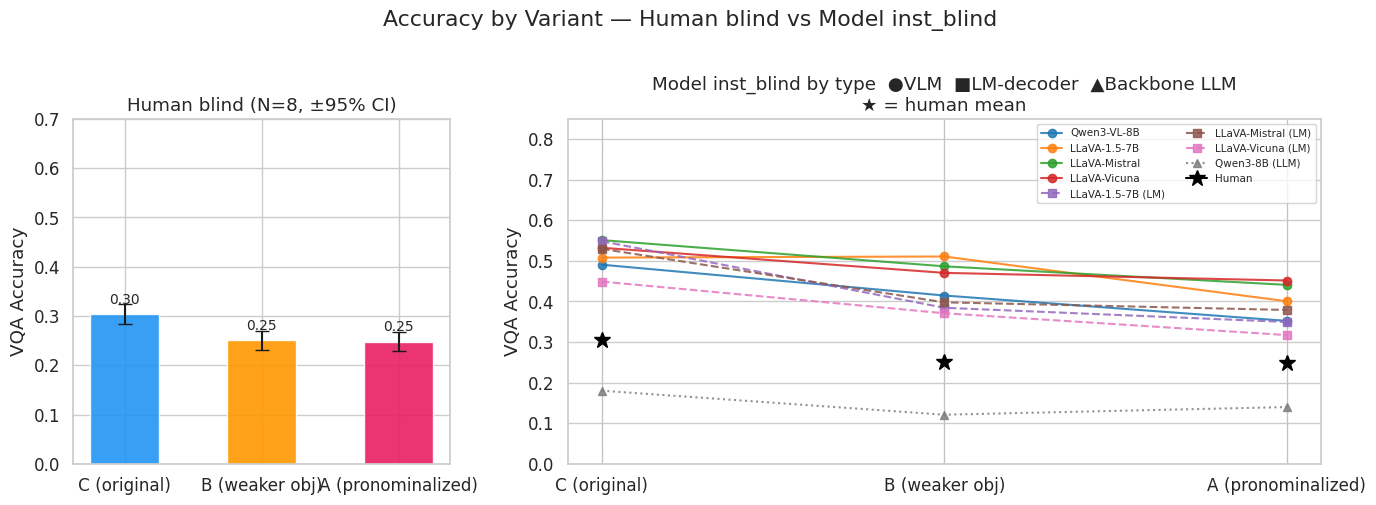

In [41]:
# Accuracy by variant — human (blind) + all model types (inst_blind)
# Three model types differentiated by marker:
#   VLM (pretrained)   : solid line, circle marker
#   LM-decoder         : dashed line, square marker  (VLM backbone extracted as LM)
#   Backbone LLM       : dotted line, triangle marker (standalone LLM, no vision)
from collections import defaultdict

_CT      = {'question': 'C', 'weaker_object': 'B', 'pronominalized': 'A'}
_q_ids   = set(df['question_id'].tolist())
_RESULTS = BASE / 'evaluation/logits'

MODEL_GROUPS = {
    'vlm': {
        'dir': _RESULTS / 'pretrained',
        'models': {
            'Qwen3-VL-8B':   'Qwen3-VL-8B-Instruct',
            'LLaVA-1.5-7B':  'llava-1.5-7b-hf',
            'LLaVA-Mistral': 'llava-v1.6-mistral-7b-hf',
            'LLaVA-Vicuna':  'llava-v1.6-vicuna-7b-hf',
        },
        'linestyle': '-',  'marker': 'o', 'label_suffix': '(VLM)',
    },
    'lm_decoder': {
        'dir': _RESULTS / 'lm_decoder/pretrained',
        'models': {
            'LLaVA-1.5-7B\n(LM)':  'llava-1.5-7b-hf',
            'LLaVA-Mistral\n(LM)': 'llava-v1.6-mistral-7b-hf',
            'LLaVA-Vicuna\n(LM)':  'llava-v1.6-vicuna-7b-hf',
        },
        'linestyle': '--', 'marker': 's', 'label_suffix': '(LM-dec)',
    },
    'backbone': {
        'dir': _RESULTS / 'backbone/pretrained',
        'models': {
            'Qwen3-8B\n(LLM)': 'Qwen3-8B',
        },
        'linestyle': ':', 'marker': '^', 'label_suffix': '(LLM)',
    },
}

# Load per-variant means for all models
_acc = {}  # (group, label) → {var: mean_acc}
for gname, ginfo in MODEL_GROUPS.items():
    for label, mdir in ginfo['models'].items():
        path = ginfo['dir'] / mdir / 'vqa_1k_control_inst_blind.jsonl'
        if not path.exists(): continue
        raw = defaultdict(list)
        for line in open(path):
            ex = json.loads(line)
            qid = int(ex['question_id'])
            if qid not in _q_ids: continue
            gt = mapper.get_answers(qid)
            ga = ex.get('generated_answers', {})
            for ct, var in _CT.items():
                ans = _clean_answer(ga.get(ct, ''))
                if ans and gt:
                    raw[var].append(vqa_accuracy(ans, gt))
        _acc[(gname, label)] = {var: float(np.mean(v)) if v else np.nan
                                 for var, v in raw.items()}

# Human stats
acc_var = df.groupby('variant')['accuracy'].agg(['mean','sem']).loc[VARIANT_ORDER]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [1, 2]})

# Left: human bar chart with CI
ax = axes[0]
bars = ax.bar(
    [VARIANT_LABELS[v] for v in VARIANT_ORDER],
    acc_var['mean'], yerr=acc_var['sem'] * 1.96,
    color=[VARIANT_COLORS[v] for v in VARIANT_ORDER],
    capsize=5, width=0.5, edgecolor='white', alpha=0.9
)
for bar, (_, row) in zip(bars, acc_var.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2, row['mean'] + 0.015,
            f"{row['mean']:.2f}", ha='center', va='bottom', fontsize=10)
ax.set_ylabel('VQA Accuracy')
ax.set_title('Human blind (N=8, ±95% CI)')
ax.set_ylim(0, 0.7)

# Right: line plot for all model types
ax = axes[1]
x_pos  = np.arange(len(VARIANT_ORDER))
cmap   = plt.get_cmap('tab10')
color_idx = 0
color_map = {}

for gname, ginfo in MODEL_GROUPS.items():
    ls = ginfo['linestyle']
    mk = ginfo['marker']
    for label, mdir in ginfo['models'].items():
        key = (gname, label)
        if key not in _acc: continue
        means = [_acc[key].get(var, np.nan) for var in VARIANT_ORDER]
        if all(np.isnan(m) for m in means): continue
        short = label.replace('\n', ' ')
        color = cmap(color_idx % 10)
        color_map[short] = color
        ax.plot(x_pos, means, linestyle=ls, marker=mk, color=color,
                label=short, linewidth=1.5, markersize=6, alpha=0.85)
        color_idx += 1

# Human mean as horizontal reference lines per variant
for i, var in enumerate(VARIANT_ORDER):
    ax.axvline(i, color='gray', lw=0.4, ls='--', alpha=0.3)
    ax.plot(i, acc_var.loc[var, 'mean'], marker='*', markersize=12,
            color='black', zorder=5,
            label='Human' if i == 0 else '_nolegend_')

ax.set_xticks(x_pos)
ax.set_xticklabels([VARIANT_LABELS[v] for v in VARIANT_ORDER])
ax.set_ylabel('VQA Accuracy')
ax.set_title('Model inst_blind by type  ●VLM  ■LM-decoder  ▲Backbone LLM\n★ = human mean')
ax.set_ylim(0, 0.85)
ax.legend(fontsize=7.5, ncol=2, loc='upper right', framealpha=0.8)

plt.suptitle('Accuracy by Variant — Human blind vs Model inst_blind', y=1.01)
plt.tight_layout()
plt.show()


In [42]:
# Per-participant accuracy by variant
pp = df.groupby(['participant','variant'])['accuracy'].mean().unstack()[VARIANT_ORDER]
print('Per-participant accuracy:')
print(pp.round(3))
print(f'\nMean degradation C→A: {(pp["C"] - pp["A"]).mean():.3f}')

Per-participant accuracy:
variant          C      B      A
participant                     
0X4B4L3T     0.220  0.191  0.183
BEK0Y4W3     0.231  0.212  0.253
BTTWUQG4     0.341  0.258  0.237
DYAN3RF8     0.309  0.247  0.239
FXDCPFHM     0.320  0.272  0.296
HGIX7HE0     0.301  0.215  0.215
IV0PL083     0.382  0.331  0.331
J0OU3FTE     0.355  0.282  0.255
JOJCF28V     0.371  0.277  0.272
OBRNN1JM     0.331  0.272  0.280
ON7P7X1E     0.258  0.215  0.196
TRFMV4H2     0.231  0.218  0.226
Y2IBXIJX     0.301  0.263  0.242

Mean degradation C→A: 0.056


## 2. Confidence by Variant

Confidence (1-5) by variant:
          mean    sem
variant              
C        3.217  0.029
B        3.181  0.030
A        3.107  0.030


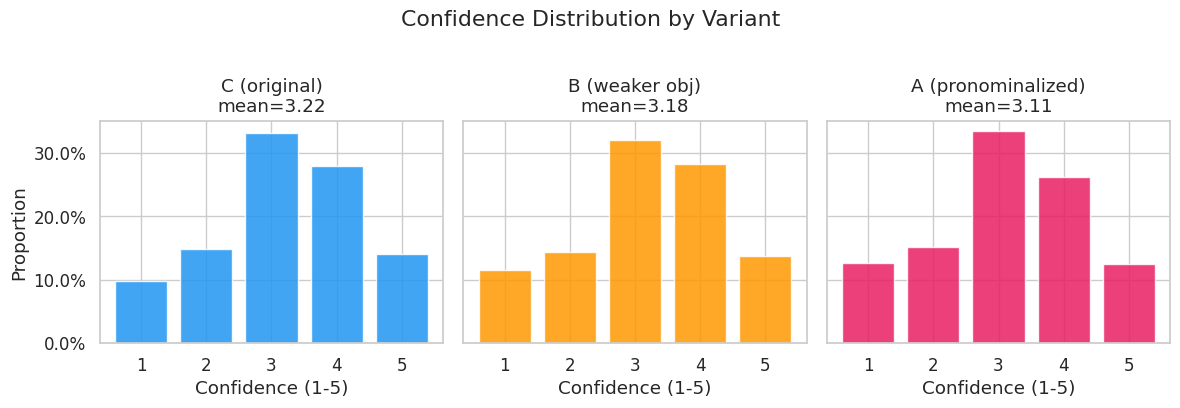

In [43]:
conf_var = df.groupby('variant')['confidence'].agg(['mean','sem'])
conf_var = conf_var.loc[VARIANT_ORDER]
print('Confidence (1-5) by variant:')
print(conf_var.round(3))

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for ax, var in zip(axes, VARIANT_ORDER):
    sub = df[df['variant'] == var]['confidence']
    counts = sub.value_counts().sort_index()
    ax.bar(counts.index, counts.values / counts.sum(),
           color=VARIANT_COLORS[var], edgecolor='white', alpha=0.85)
    ax.set_title(f'{VARIANT_LABELS[var]}\nmean={sub.mean():.2f}')
    ax.set_xlabel('Confidence (1-5)')
    ax.set_xticks([1,2,3,4,5])
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].set_ylabel('Proportion')
plt.suptitle('Confidence Distribution by Variant', y=1.02)
plt.tight_layout()
plt.show()

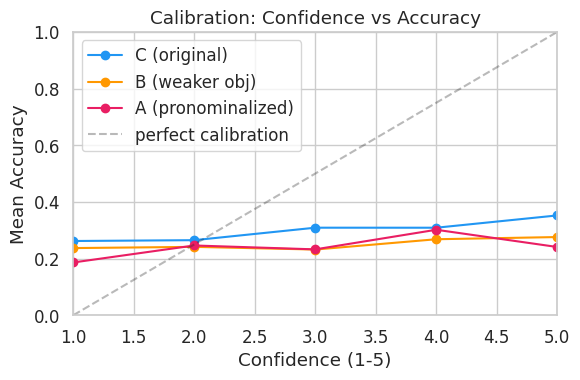

In [44]:
# Accuracy vs confidence (calibration check)
cal = df.groupby(['variant','confidence'])['accuracy'].mean().unstack(level=0)
fig, ax = plt.subplots(figsize=(6,4))
for var in VARIANT_ORDER:
    if var in cal.columns:
        ax.plot(cal.index, cal[var], marker='o', label=VARIANT_LABELS[var],
                color=VARIANT_COLORS[var])
ax.plot([1,5],[0,1], 'k--', alpha=0.3, label='perfect calibration')
ax.set_xlabel('Confidence (1-5)')
ax.set_ylabel('Mean Accuracy')
ax.set_title('Calibration: Confidence vs Accuracy')
ax.legend()
ax.set_xlim(1,5); ax.set_ylim(0,1)
plt.tight_layout()
plt.show()

## 3. Response Time

Response time (seconds) by variant:
         median   mean
variant               
A          4.02  11.92
B          4.29   6.47
C          4.17   7.43


/tmp/ipykernel_3969674/897593536.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_plot, labels=[VARIANT_LABELS[v] for v in VARIANT_ORDER],


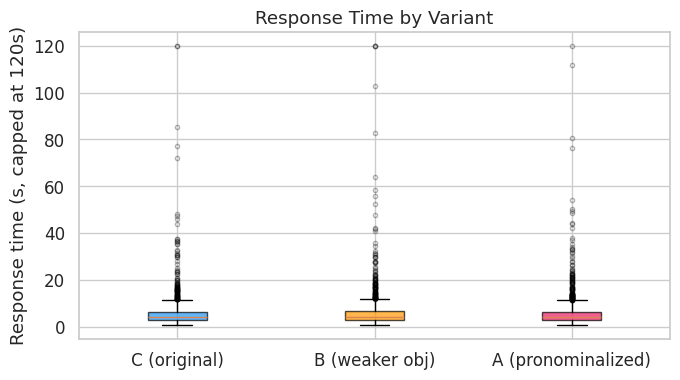

In [45]:
# Cap outliers at 120s for visualization
df['time_s_cap'] = df['time_s'].clip(upper=120)

time_var = df.groupby('variant')['time_s'].agg(['median','mean'])
print('Response time (seconds) by variant:')
print(time_var.round(2))

fig, ax = plt.subplots(figsize=(7, 4))
data_plot = [df[df['variant']==v]['time_s_cap'].values for v in VARIANT_ORDER]
bp = ax.boxplot(data_plot, labels=[VARIANT_LABELS[v] for v in VARIANT_ORDER],
                patch_artist=True, showfliers=True,
                flierprops=dict(marker='.', alpha=0.3))
for patch, var in zip(bp['boxes'], VARIANT_ORDER):
    patch.set_facecolor(VARIANT_COLORS[var])
    patch.set_alpha(0.7)
ax.set_ylabel('Response time (s, capped at 120s)')
ax.set_title('Response Time by Variant')
plt.tight_layout()
plt.show()

In [46]:
# Response time by session
time_sess = df.groupby(['session','variant'])['time_s'].median().unstack()[VARIANT_ORDER]
print('Median response time (s) by session × variant:')
print(time_sess.round(2))

Median response time (s) by session × variant:
variant     C     B     A
session                  
1        4.89  4.65  4.42
2        4.25  4.04  4.03
3        3.62  4.07  3.53


## 4. Accuracy by Entity Type and Op

In [47]:
# ── Accuracy by entity group — all model groups (inst_blind) ─────────────────
from collections import defaultdict as _dd

_CT    = {'question': 'C', 'weaker_object': 'B', 'pronominalized': 'A'}
_q_ids = set(df['question_id'].tolist())

ALL_MODEL_GROUPS = {
    'VLM': {
        'dir': BASE / 'evaluation/logits/pretrained',
        'models': {
            'Qwen3-VL-8B': 'Qwen3-VL-8B-Instruct',
            'LLaVA-1.5-7B': 'llava-1.5-7b-hf',
            'LLaVA-Mistral': 'llava-v1.6-mistral-7b-hf',
            'LLaVA-Vicuna':  'llava-v1.6-vicuna-7b-hf',
        },
    },
    'LM-decoder': {
        'dir': BASE / 'evaluation/logits/lm_decoder/pretrained',
        'models': {
            'LLaVA-1.5 (LM)':   'llava-1.5-7b-hf',
            'LLaVA-Mistral (LM)':'llava-v1.6-mistral-7b-hf',
            'LLaVA-Vicuna (LM)': 'llava-v1.6-vicuna-7b-hf',
        },
    },
    'Backbone LLM': {
        'dir': BASE / 'evaluation/logits/backbone/pretrained',
        'models': {
            'Qwen3-8B': 'Qwen3-8B',
        },
    },
}
GROUP_COLORS = {'VLM': '#E91E63', 'LM-decoder': '#2196F3', 'Backbone LLM': '#FF9800'}

_ent_map = df[['question_id','ent']].drop_duplicates().set_index('question_id')['ent']

# Load per-model per-question accuracy, then compute group means per entity
group_ent_acc = {}   # gname → ent → variant → mean_acc
group_q_acc   = {}   # gname → per-question DataFrame (mean across group models)

for gname, ginfo in ALL_MODEL_GROUPS.items():
    model_dfs = []
    for label, mdir in ginfo['models'].items():
        path = ginfo['dir'] / mdir / 'vqa_1k_control_inst_blind.jsonl'
        if not path.exists(): continue
        _raw = _dd(lambda: _dd(list))
        for line in open(path):
            ex  = json.loads(line)
            qid = int(ex['question_id'])
            if qid not in _q_ids: continue
            gt  = mapper.get_answers(qid)
            ga  = ex.get('generated_answers', {})
            for ct, var in _CT.items():
                ans = _clean_answer(ga.get(ct, ''))
                if ans and gt:
                    _raw[qid][var].append(vqa_accuracy(ans, gt))
        rows_m = [{'question_id': qid,
                   **{var: float(np.mean(_raw[qid][var])) if _raw[qid][var] else np.nan
                      for var in VARIANT_ORDER}}
                  for qid in _q_ids]
        model_dfs.append(pd.DataFrame(rows_m).set_index('question_id'))

    if not model_dfs: continue
    # Mean across models in the group
    grp_mean = pd.concat(model_dfs).groupby(level=0).mean()
    group_q_acc[gname] = grp_mean

    # Per entity-group mean
    grp2 = grp_mean.join(_ent_map)
    group_ent_acc[gname] = grp2.groupby('ent')[VARIANT_ORDER].mean()

# Human accuracy per original entity type
acc_ent = df.groupby(['ent','variant'])['accuracy'].mean().unstack()[VARIANT_ORDER]
ENT_ORDER = sorted(acc_ent.index.tolist())
acc_ent = acc_ent.reindex(ENT_ORDER)

print('Groups loaded:', list(group_ent_acc.keys()))

# Question count and yes/no count per entity
ent_n = df[df['variant'] == 'C'].groupby('ent')['question_id'].nunique().rename('N')

# Yes/no questions: look up answer_type from VQA annotations
qid_to_ent = df[df['variant'] == 'C'].drop_duplicates('question_id').set_index('question_id')['ent']
yesno_counts = {}
for qid, ent in qid_to_ent.items():
    atype = mapper.annotations.get(int(qid), {}).get('answer_type', '')
    if atype == 'yes/no':
        yesno_counts[ent] = yesno_counts.get(ent, 0) + 1
ent_yesno = pd.Series(yesno_counts, name='yes/no').reindex(ENT_ORDER).fillna(0).astype(int)

display_ent = acc_ent.round(3).join(ent_n).join(ent_yesno)

# Add total row: mean for C/B/A, sum for N and yes/no
total = pd.Series({
    'C':      display_ent['C'].mean(),
    'B':      display_ent['B'].mean(),
    'A':      display_ent['A'].mean(),
    'N':      display_ent['N'].sum(),
    'yes/no': display_ent['yes/no'].sum(),
}, name='Total')
display_ent = pd.concat([display_ent, total.to_frame().T])
display_ent[['N','yes/no']] = display_ent[['N','yes/no']].astype(object)  # allow mixed int/float
display_ent.loc['Total', ['N','yes/no']] = display_ent.loc['Total', ['N','yes/no']].astype(int)

print('\nHuman accuracy by entity type × variant:')
print(display_ent.round(3)) 

Groups loaded: ['VLM', 'LM-decoder', 'Backbone LLM']

Human accuracy by entity type × variant:
             C      B      A     N yes/no
animal   0.403  0.327  0.318  17.0    6.0
food     0.357  0.290  0.324  16.0    5.0
object   0.233  0.182  0.123  27.0    4.0
other    0.361  0.361  0.382  11.0    4.0
person   0.217  0.161  0.204  26.0    6.0
place    0.440  0.304  0.388   7.0    4.0
product  0.344  0.293  0.209   7.0    2.0
text     0.167  0.205  0.128   6.0    2.0
vehicle  0.392  0.333  0.337   7.0    3.0
Total    0.324  0.273  0.268   124     36


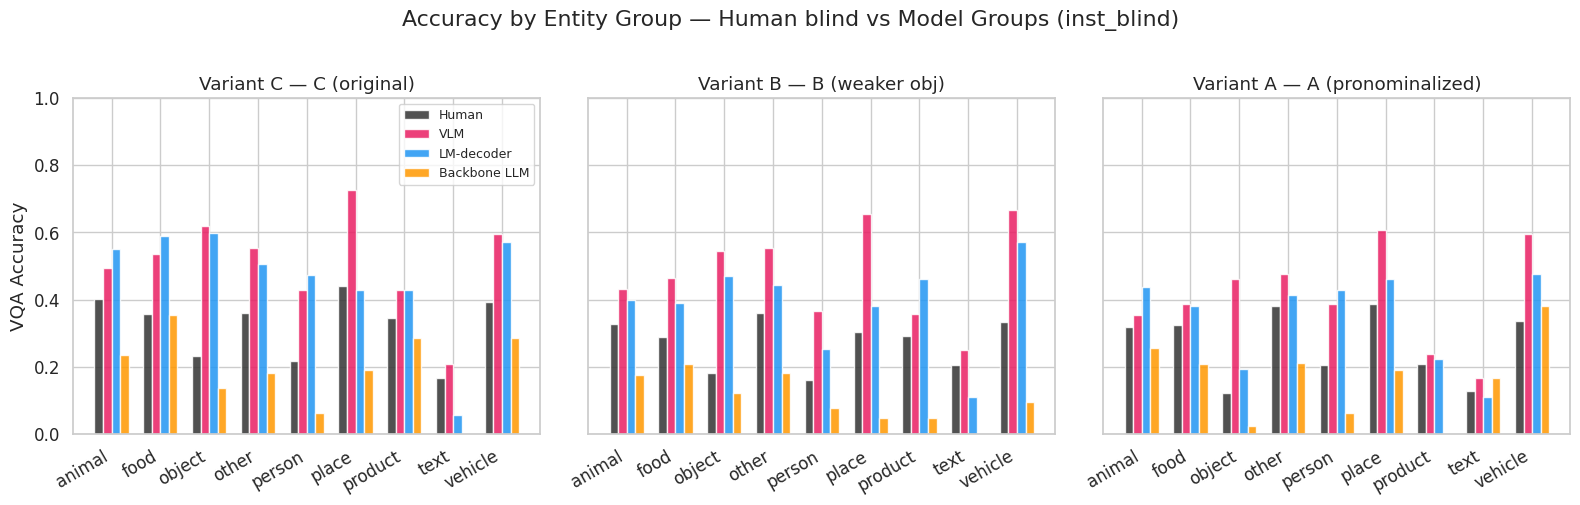

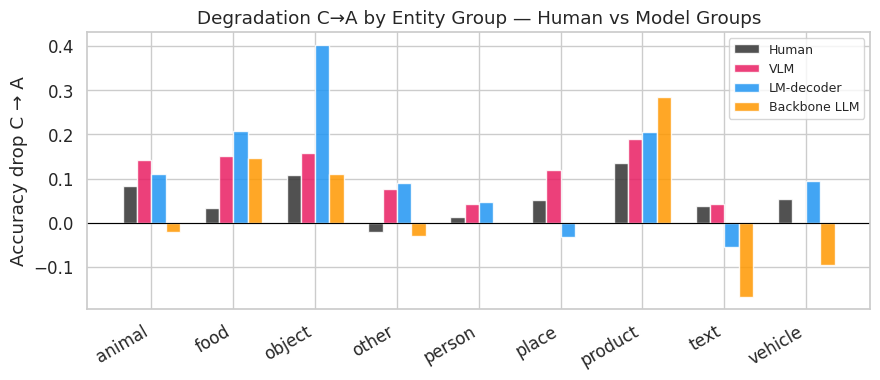

In [48]:
# ── Grouped bar: human + VLM / LM-decoder / Backbone per entity group ─────────
ent_order = ENT_ORDER
x         = np.arange(len(ent_order))
srcs      = [('Human', None, '#333333')] + [(g, None, GROUP_COLORS[g]) for g in ALL_MODEL_GROUPS]
n_src     = len(srcs)
w         = 0.7 / n_src
offsets   = np.linspace(-(n_src-1)/2, (n_src-1)/2, n_src) * w

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax_i, var in enumerate(VARIANT_ORDER):
    ax = axes[ax_i]
    for (label, _, color), offset in zip(srcs, offsets):
        if label == 'Human':
            vals = [acc_ent.loc[e, var] if e in acc_ent.index else np.nan for e in ent_order]
        else:
            mea = group_ent_acc.get(label, pd.DataFrame())
            vals = [mea.loc[e, var] if e in mea.index else np.nan for e in ent_order]
        ax.bar(x + offset, vals, w, color=color, alpha=0.85, edgecolor='white',
               label=label if ax_i == 0 else '_nolegend_')
    ax.set_xticks(x); ax.set_xticklabels(ent_order, rotation=30, ha='right')
    ax.set_title(f'Variant {var} — {VARIANT_LABELS[var]}')
    ax.set_ylim(0, 1)
    if ax_i == 0:
        ax.set_ylabel('VQA Accuracy')

axes[0].legend(fontsize=9, loc='upper right')
plt.suptitle('Accuracy by Entity Group — Human blind vs Model Groups (inst_blind)', y=1.01)
plt.tight_layout()
plt.show()

# ── Degradation C→A: human + 3 model groups per entity ───────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
human_deg = (acc_ent['C'] - acc_ent['A']).reindex(ent_order)

all_degs = [('Human', human_deg, '#333333')] + [
    (gname, (group_ent_acc[gname]['C'] - group_ent_acc[gname]['A']).reindex(ent_order),
     GROUP_COLORS[gname])
    for gname in ALL_MODEL_GROUPS if gname in group_ent_acc
]
n    = len(all_degs)
w    = 0.7 / n
offs = np.linspace(-(n-1)/2, (n-1)/2, n) * w

for (label, deg_vals, color), off in zip(all_degs, offs):
    ax.bar(x + off, deg_vals, w, color=color, alpha=0.85,
           edgecolor='white', label=label)

ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(ent_order, rotation=30, ha='right')
ax.set_ylabel('Accuracy drop C → A')
ax.set_title('Degradation C→A by Entity Group — Human vs Model Groups')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


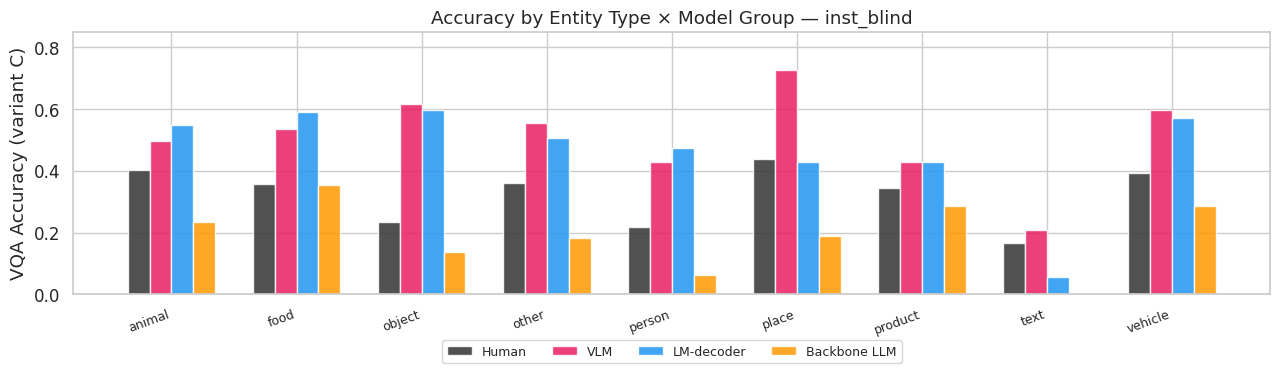

In [49]:
# ── Accuracy by entity type × model group (variant C, inst_blind) ────────────
# X-axis: entity types  |  bars: model groups (Human / VLM / LM-decoder / Backbone)
group_order  = ['Human'] + list(ALL_MODEL_GROUPS.keys())
GROUP_COLORS_EXT = {'Human': '#333333', **GROUP_COLORS}

x        = np.arange(len(ENT_ORDER))
n_groups = len(group_order)
w        = 0.7 / n_groups
offsets  = np.linspace(-(n_groups-1)/2, (n_groups-1)/2, n_groups) * w

fig, ax = plt.subplots(figsize=(13, 4))
for gname, offset in zip(group_order, offsets):
    if gname == 'Human':
        vals = [acc_ent.loc[e, 'C'] if e in acc_ent.index else np.nan for e in ENT_ORDER]
    else:
        mea  = group_ent_acc.get(gname, pd.DataFrame())
        vals = [mea.loc[e, 'C'] if e in mea.index else np.nan for e in ENT_ORDER]
    ax.bar(x + offset, vals, w, color=GROUP_COLORS_EXT[gname],
           alpha=0.85, edgecolor='white', label=gname)

ax.set_xticks(x)
ax.set_xticklabels(ENT_ORDER, fontsize=9, rotation=20, ha='right')
ax.set_ylabel('VQA Accuracy (variant C)')
ax.set_title('Accuracy by Entity Type × Model Group — inst_blind')
ax.set_ylim(0, 0.85)
ax.legend(fontsize=9, ncols=4, loc='upper center',bbox_to_anchor=(0.5, -0.15))
# ax.axhline(0.5, color='gray', ls='--', lw=0.7)
plt.tight_layout()
plt.show()

## 5. Question-Level Difficulty

NameError: name 's2' is not defined

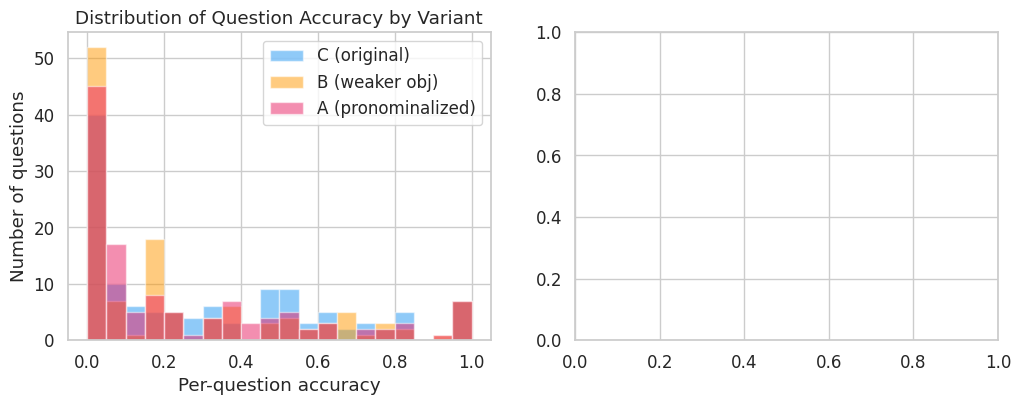

In [50]:
# Human difficulty h(q) per variant = 1 - accuracy
q_acc = df.groupby(['question_id','variant'])['accuracy'].mean().unstack()[VARIANT_ORDER]
q_acc['h_C'] = 1 - q_acc['C']
q_acc['degradation'] = q_acc['C'] - q_acc['A']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution of per-question accuracy
ax = axes[0]
for var in VARIANT_ORDER:
    ax.hist(q_acc[var].dropna(), bins=20, alpha=0.5,
            label=VARIANT_LABELS[var], color=VARIANT_COLORS[var])
ax.set_xlabel('Per-question accuracy')
ax.set_ylabel('Number of questions')
ax.set_title('Distribution of Question Accuracy by Variant')
ax.legend()

# Human accuracy C vs blind model accuracy
ax = axes[1]
q_merged = q_acc.reset_index().merge(s2[['question_id','acc_original','signal_score']], on='question_id')
sc = ax.scatter(q_merged['acc_original'], q_merged['C'],
                c=q_merged['signal_score'], cmap='RdYlGn', alpha=0.6, s=25)
plt.colorbar(sc, ax=ax, label='signal_score')
ax.set_xlabel('Model blind accuracy (acc_original)')
ax.set_ylabel('Human accuracy (variant C)')
ax.set_title('Human vs Model Blind Accuracy (per question)')
r = q_merged[['acc_original','C']].dropna().corr().iloc[0,1]
ax.text(0.05, 0.9, f'r = {r:.3f}', transform=ax.transAxes, fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
# Enrich with question text (from s4 = s2_v4, variant C)
q_lookup = {e['question_id']: e['question_en']
            for e in json.load(open(BASE/'experiment/s2_v4/s4_question.json'))}

q_acc_full = q_acc.reset_index().copy()
q_acc_full['question_en'] = q_acc_full['question_id'].map(q_lookup)

print('10 hardest (C):')
for _, row in q_acc_full.nsmallest(10,'C').iterrows():
    print(f"  {row['question_id']} acc={row['C']:.2f} deg={row['degradation']:.2f}  {row['question_en']}")

print('\n10 easiest (C):')
for _, row in q_acc_full.nlargest(10,'C').iterrows():
    print(f"  {row['question_id']} acc={row['C']:.2f} deg={row['degradation']:.2f}  {row['question_en']}")

10 hardest (C):
  1342072 acc=0.00 deg=0.00  What kind of information does the yellow and white book look like it contains?
  73521003 acc=0.00 deg=0.00  What location is the luggage at?
  91236000 acc=0.00 deg=-0.01  What formation are the aircraft in?
  121442004 acc=0.00 deg=-0.09  How many kids have glasses?
  121839003 acc=0.00 deg=0.00  What are the ladies wearing on their head's?
  169996009 acc=0.00 deg=0.00  What is the name of the store closest to the van?
  187196001 acc=0.00 deg=0.00  What does the shirt say?
  211837003 acc=0.00 deg=0.00  How many zebra are in the picture?
  213359003 acc=0.00 deg=-0.04  What does the man's gesture mean?
  226154000 acc=0.00 deg=0.00  What language is the writing at the top of the bus in?

10 easiest (C):
  199876000 acc=1.00 deg=0.00  Are these women friends?
  219492002 acc=1.00 deg=0.00  Are cats really afraid to get into water?
  335047002 acc=1.00 deg=0.00  Is there a hot dog in there?
  374111001 acc=1.00 deg=0.00  Are the chips fres

## 6. Human vs Model Alignment

In [51]:
# Spearman / Pearson / Kendall τ — human blind vs model inst_blind per question
from scipy.stats import pearsonr, spearmanr, kendalltau

results = []
for var in VARIANT_ORDER:
    h_var = q_acc[var].dropna().rename('human')
    for label, mdf in model_q_acc.items():
        merged = h_var.reset_index().merge(
            mdf[var].dropna().reset_index(), on='question_id'
        ).dropna()
        if len(merged) < 5: continue
        r,   _ = pearsonr( merged['human'], merged[var])
        rho, _ = spearmanr(merged['human'], merged[var])
        tau, _ = kendalltau(merged['human'], merged[var])
        results.append({'model': label, 'type': MODEL_TYPE.get(label, '?'), 'variant': var,
                        'pearson_r': r, 'spearman_rho': rho,
                        'kendall_tau': tau, 'n': len(merged)})

rdf = pd.DataFrame(results)

# Print grouped by model type
print('Correlation: human blind accuracy vs model inst_blind accuracy per question')
print('(Pearson r | Spearman ρ | Kendall τ)')
print(f'{"model":22}  {"type":12}  {"C":>22}  {"B":>22}  {"A":>22}')
print('-' * 105)
for mtype in ['VLM', 'LM-decoder', 'Backbone LLM']:
    for label in model_q_acc:
        if MODEL_TYPE.get(label) != mtype: continue
        parts = []
        for var in VARIANT_ORDER:
            sub = rdf[(rdf.model == label) & (rdf.variant == var)]
            if sub.empty:
                parts.append(f'{"n/a":>22}')
            else:
                r = sub.iloc[0]
                parts.append(f'{r.pearson_r:+.3f} {r.spearman_rho:+.3f} {r.kendall_tau:+.3f}')
        print(f'{label:22}  {mtype:12}  {"  ".join(parts)}')
    print()


Correlation: human blind accuracy vs model inst_blind accuracy per question
(Pearson r | Spearman ρ | Kendall τ)
model                   type                               C                       B                       A
---------------------------------------------------------------------------------------------------------
Qwen3-VL-8B             VLM           +0.515 +0.552 +0.450  +0.564 +0.593 +0.505  +0.506 +0.492 +0.411
LLaVA-1.5-7B            VLM           +0.462 +0.463 +0.391  +0.461 +0.508 +0.432  +0.497 +0.533 +0.454
LLaVA-Mistral           VLM           +0.417 +0.431 +0.346  +0.514 +0.568 +0.484  +0.440 +0.470 +0.393
LLaVA-Vicuna            VLM           +0.400 +0.387 +0.315  +0.462 +0.477 +0.405  +0.477 +0.506 +0.427
InternVL-1B             VLM           +0.579 +0.527 +0.439  +0.609 +0.564 +0.480  +0.653 +0.613 +0.521
InternVL-2B             VLM           +0.420 +0.439 +0.363  +0.441 +0.473 +0.400  +0.591 +0.650 +0.545
InternVL-8B             VLM           +0.452 +0.434 +0

In [52]:
# Summary: mean accuracy + degradation C→A (inst_blind models vs human blind)
print(f'{"":25}  {"type":12}  {"C":>6} {"A":>6} {"C→A deg":>8}')
print('-' * 62)
for mtype in ['VLM', 'LM-decoder', 'Backbone LLM']:
    for label, mdf in model_q_acc.items():
        if MODEL_TYPE.get(label) != mtype: continue
        c = mdf['C'].mean(); a = mdf['A'].mean()
        print(f'{label:25}  {mtype:12}  {c:.3f}  {a:.3f}  {c-a:+.3f}')
    print()
h_c = df[df.variant=="C"]["accuracy"].mean()
h_a = df[df.variant=="A"]["accuracy"].mean()
n_p = df['participant'].nunique()
print(f'{f"Human (blind, N={n_p})":25}  {"—":12}  {h_c:.3f}  {h_a:.3f}  {h_c-h_a:+.3f}')

                           type               C      A  C→A deg
--------------------------------------------------------------
Qwen3-VL-8B                VLM           0.491  0.352  +0.138
LLaVA-1.5-7B               VLM           0.508  0.401  +0.108
LLaVA-Mistral              VLM           0.551  0.441  +0.110
LLaVA-Vicuna               VLM           0.532  0.452  +0.081
InternVL-1B                VLM           0.325  0.293  +0.032
InternVL-2B                VLM           0.460  0.427  +0.032
InternVL-8B                VLM           0.379  0.323  +0.056

LLaVA-1.5 (LM)             LM-decoder    0.548  0.349  +0.199
LLaVA-Mistral (LM)         LM-decoder    0.530  0.379  +0.151
LLaVA-Vicuna (LM)          LM-decoder    0.449  0.317  +0.132

Qwen3-8B                   Backbone LLM  0.180  0.140  +0.040

Human (blind, N=13)        —             0.304  0.248  +0.056


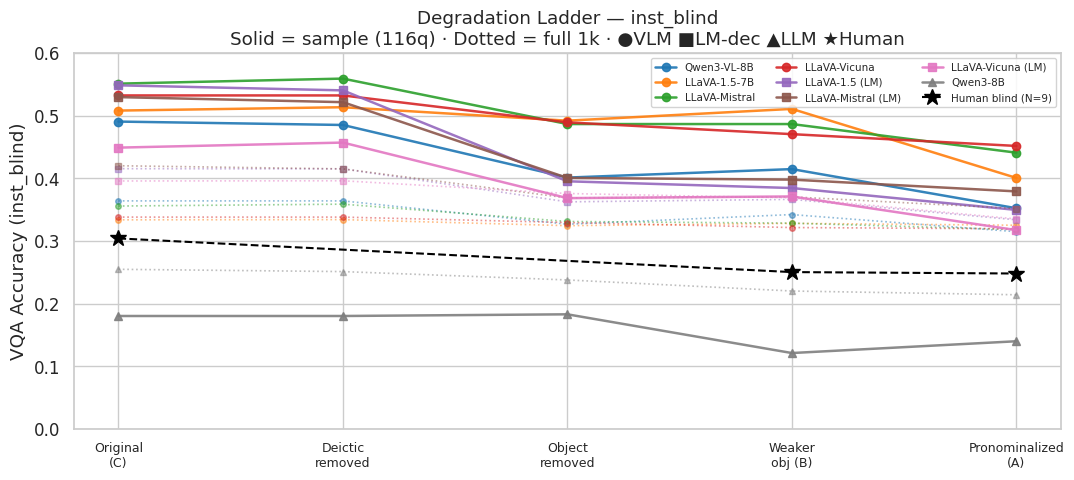

In [53]:
# ── Degradation ladder: full 1k (dotted) vs s2_v2 sample (solid) ─────────────
# inst_blind condition for all model types + human (3 points: C/B/A only)
# Markers: ● VLM  ■ LM-decoder  ▲ Backbone LLM  ★ Human
from collections import defaultdict as _dd

CONTROL_TYPES  = ['question','deictic_removed','object_removed','weaker_object','pronominalized']
CT_LABELS      = ['Original\n(C)','Deictic\nremoved','Object\nremoved','Weaker\nobj (B)','Pronominalized\n(A)']
# Indices where human data maps to
HUMAN_CT_IDX   = {'C': 0, 'B': 3, 'A': 4}  # question, weaker_object, pronominalized

LOGIT_BASE = BASE / 'evaluation/logits'
MODEL_GROUPS = {
    'vlm': {
        'dir': LOGIT_BASE / 'pretrained',
        'marker': 'o', 'models': {
            'Qwen3-VL-8B':    'Qwen3-VL-8B-Instruct',
            'LLaVA-1.5-7B':   'llava-1.5-7b-hf',
            'LLaVA-Mistral':  'llava-v1.6-mistral-7b-hf',
            'LLaVA-Vicuna':   'llava-v1.6-vicuna-7b-hf',
        }
    },
    'lm_decoder': {
        'dir': LOGIT_BASE / 'lm_decoder/pretrained',
        'marker': 's', 'models': {
            'LLaVA-1.5 (LM)':  'llava-1.5-7b-hf',
            'LLaVA-Mistral (LM)': 'llava-v1.6-mistral-7b-hf',
            'LLaVA-Vicuna (LM)':  'llava-v1.6-vicuna-7b-hf',
        }
    },
    'backbone': {
        'dir': LOGIT_BASE / 'backbone/pretrained',
        'marker': '^', 'models': {
            'Qwen3-8B': 'Qwen3-8B',
        }
    },
}

def load_ct_acc(model_dir, qid_filter=None):
    path = model_dir / 'vqa_1k_control_inst_blind.jsonl'
    if not path.exists():
        return {}
    ct_acc = _dd(list)
    for line in open(path):
        ex  = json.loads(line)
        qid = int(ex['question_id'])
        if qid_filter and qid not in qid_filter:
            continue
        gt = mapper.get_answers(qid)
        ga = ex.get('generated_answers', {})
        for ct in CONTROL_TYPES:
            ans = _clean_answer(ga.get(ct, ''))
            if ans and gt:
                ct_acc[ct].append(vqa_accuracy(ans, gt))
    return {ct: float(np.mean(v)) for ct, v in ct_acc.items() if v}

sample_qids = set(df['question_id'].tolist())
x = np.arange(len(CONTROL_TYPES))

# Collect data
curves = []  # list of (label, gname, marker, means_sample, means_full)
for gname, ginfo in MODEL_GROUPS.items():
    for label, mdir in ginfo['models'].items():
        mpath = ginfo['dir'] / mdir
        s_acc = load_ct_acc(mpath, qid_filter=sample_qids)
        f_acc = load_ct_acc(mpath, qid_filter=None)
        if not s_acc and not f_acc:
            continue
        s_vals = [s_acc.get(ct, np.nan) for ct in CONTROL_TYPES]
        f_vals = [f_acc.get(ct, np.nan) for ct in CONTROL_TYPES]
        curves.append((label, gname, ginfo['marker'], s_vals, f_vals))

# Human 3-point curve
h_vals = [np.nan] * len(CONTROL_TYPES)
for var, idx in HUMAN_CT_IDX.items():
    h_vals[idx] = df[df.variant == var]['accuracy'].mean()

# ── Plot ──────────────────────────────────────────────────────────────────────
cmap = plt.get_cmap('tab10')
label_colors = {c[0]: cmap(i % 10) for i, c in enumerate(curves)}

fig, ax = plt.subplots(figsize=(11, 5))

for label, gname, marker, s_vals, f_vals in curves:
    color = label_colors[label]
    # Sample: solid line
    ax.plot(x, s_vals, color=color, marker=marker, ls='-',
            linewidth=1.8, markersize=6, alpha=0.9,
            label=f'{label}')
    # Full 1k: dotted line, no legend entry
    if any(not np.isnan(v) for v in f_vals):
        ax.plot(x, f_vals, color=color, marker=marker, ls=':',
                linewidth=1.2, markersize=4, alpha=0.5,
                label='_nolegend_')

# Human: stars at 3 points
h_x = [i for i, v in enumerate(h_vals) if not np.isnan(v)]
h_y = [v for v in h_vals if not np.isnan(v)]
ax.plot(h_x, h_y, color='black', marker='*', ls='--',
        linewidth=1.5, markersize=12, zorder=5, label='Human blind (N=9)')

ax.set_xticks(x)
ax.set_xticklabels(CT_LABELS, fontsize=9)
ax.set_ylabel('VQA Accuracy (inst_blind)')
ax.set_ylim(0, 0.6)
ax.set_title(
    'Degradation Ladder — inst_blind\n'
    'Solid = sample (116q) · Dotted = full 1k · ●VLM ■LM-dec ▲LLM ★Human'
)

# Compact legend: two columns
ax.legend(fontsize=7.5, ncol=3, loc='upper right', framealpha=0.85)
plt.tight_layout()
plt.show()


## 7. Calibration — Human Confidence vs Model Logprob Confidence

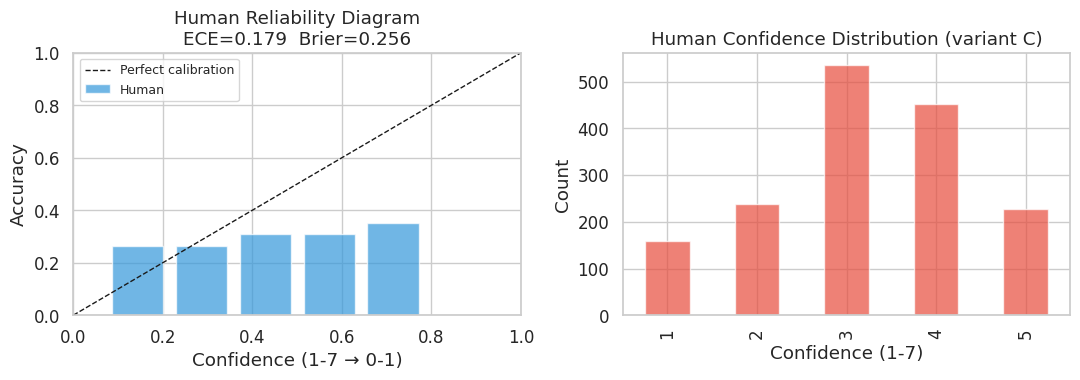

ECE:         0.1791
Brier score: 0.2555
Conf-accuracy Pearson r per participant (mean): 0.094
  0X4B4L3T: r=-0.061
  BEK0Y4W3: r=0.027
  BTTWUQG4: r=0.105
  DYAN3RF8: r=0.206
  FXDCPFHM: r=0.044
  HGIX7HE0: r=-0.054
  IV0PL083: r=0.048
  J0OU3FTE: r=0.072
  JOJCF28V: r=0.393
  OBRNN1JM: r=0.138
  ON7P7X1E: r=0.092
  TRFMV4H2: r=0.003
  Y2IBXIJX: r=0.208


In [54]:
# ── Human calibration ────────────────────────────────────────────────────────
# Human confidence is on a 1-7 scale; treat conf/7 as probability estimate
# Metrics:
#   Reliability diagram: binned confidence vs mean accuracy
#   ECE (Expected Calibration Error): weighted mean |acc - conf| per bin
#   Brier score: mean((conf/7 - correct)²)

from scipy.stats import pearsonr

cal_df = df[df.variant == 'C'].copy()
cal_df['conf_prob'] = cal_df['confidence'] / 7.0
cal_df['correct']   = cal_df['accuracy'].round().astype(float)  # 0 or 1 for Brier

N_BINS = 7
bins = np.linspace(0, 1, N_BINS + 1)
cal_df['conf_bin'] = pd.cut(cal_df['conf_prob'], bins=bins, labels=False, include_lowest=True)

bin_stats = cal_df.groupby('conf_bin').agg(
    mean_conf=('conf_prob', 'mean'),
    mean_acc=('accuracy', 'mean'),
    n=('accuracy', 'count')
).dropna()

ece   = (bin_stats['n'] / len(cal_df) * (bin_stats['mean_acc'] - bin_stats['mean_conf']).abs()).sum()
brier = ((cal_df['conf_prob'] - cal_df['correct']) ** 2).mean()

# Confidence-accuracy correlation per participant
conf_acc_corr = cal_df.groupby('participant').apply(
    lambda g: pearsonr(g['conf_prob'], g['accuracy'])[0] if len(g) > 5 else np.nan
).dropna()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Reliability diagram
ax = axes[0]
ax.bar(bin_stats['mean_conf'], bin_stats['mean_acc'],
       width=1/N_BINS * 0.8, alpha=0.7, color='#3498db', label='Human')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
ax.set_xlabel('Confidence (1-7 → 0-1)'); ax.set_ylabel('Accuracy')
ax.set_title(f'Human Reliability Diagram\nECE={ece:.3f}  Brier={brier:.3f}')
ax.legend(fontsize=9); ax.set_xlim(0, 1); ax.set_ylim(0, 1)

# Confidence distribution
ax = axes[1]
cal_df['confidence'].value_counts().sort_index().plot(kind='bar', ax=ax, color='#e74c3c', alpha=0.7)
ax.set_xlabel('Confidence (1-7)'); ax.set_ylabel('Count')
ax.set_title(f'Human Confidence Distribution (variant C)')

plt.tight_layout(); plt.show()

print(f'ECE:         {ece:.4f}')
print(f'Brier score: {brier:.4f}')
print(f'Conf-accuracy Pearson r per participant (mean): {conf_acc_corr.mean():.3f}')
for pid, r in conf_acc_corr.items():
    print(f'  {pid}: r={r:.3f}')


Qwen3-VL-8B: 36 yes/no questions with logprobs  r(P(yes),correct)=-0.332
LLaVA-1.5-7B: 38 yes/no questions with logprobs  r(P(yes),correct)=-0.051
LLaVA-Mistral: 38 yes/no questions with logprobs  r(P(yes),correct)=-0.162
LLaVA-Vicuna: 38 yes/no questions with logprobs  r(P(yes),correct)=-0.061
InternVL-1B: 36 yes/no questions with logprobs  r(P(yes),correct)=-0.266
InternVL-2B: 36 yes/no questions with logprobs  r(P(yes),correct)=-0.188
InternVL-8B: 36 yes/no questions with logprobs  r(P(yes),correct)=-0.134
LLaVA-1.5 (LM): 36 yes/no questions with logprobs  r(P(yes),correct)=-0.183
LLaVA-Mistral (LM): 37 yes/no questions with logprobs  r(P(yes),correct)=-0.413
LLaVA-Vicuna (LM): 37 yes/no questions with logprobs  r(P(yes),correct)=-0.034
Qwen3-8B: 34 yes/no questions with logprobs  r(P(yes),correct)=nan


/home/david/miniconda3/envs/aide/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


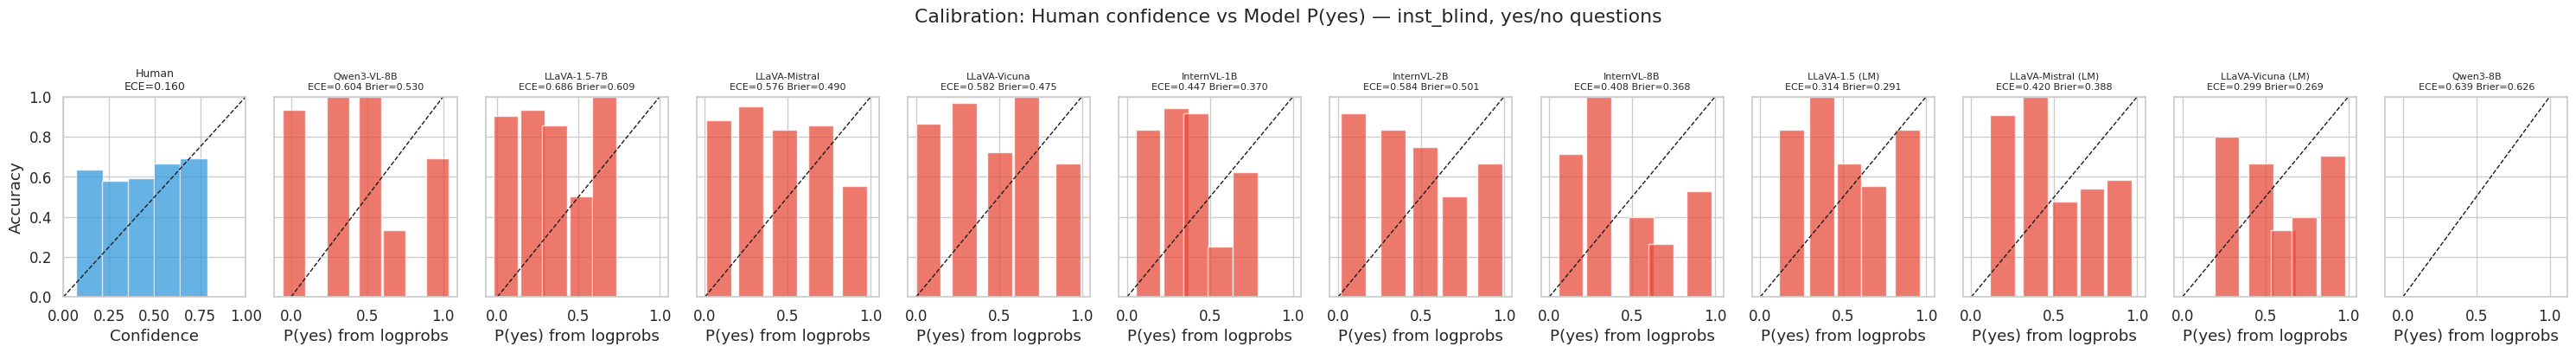

Calibration models: ['Qwen3-VL-8B', 'LLaVA-1.5-7B', 'LLaVA-Mistral', 'LLaVA-Vicuna', 'InternVL-1B', 'InternVL-2B', 'InternVL-8B', 'LLaVA-1.5 (LM)', 'LLaVA-Mistral (LM)', 'LLaVA-Vicuna (LM)', 'Qwen3-8B']


In [55]:
# ── Model calibration from logprobs (inst_blind, yes/no questions only) ──────
# For yes/no questions: extract P(yes) from top-5 logprobs of first token
# Use softmax over {yes, no} tokens to get calibrated probability
# ECE and reliability diagram compared to human calibration

import math

def extract_yn_prob(logits_content):
    """Extract P(yes) from top-5 first-token logits. Returns None if yes/no not in top-5."""
    if not logits_content: return None
    top = logits_content[0]['top_logprobs']
    yn_lp = {}
    for t in top:
        tok = t['token'].strip().lower()
        if tok in ('yes', 'no') and tok not in yn_lp:
            yn_lp[tok] = t['logprob']
    if 'yes' not in yn_lp and 'no' not in yn_lp:
        return None
    # softmax over yes/no only
    lp_yes = yn_lp.get('yes', -30.0)
    lp_no  = yn_lp.get('no',  -30.0)
    p_yes = math.exp(lp_yes) / (math.exp(lp_yes) + math.exp(lp_no))
    return p_yes

# Load inst_blind logprobs for yes/no questions
yn_qids = set(df[df.variant == 'C']['question_id'].tolist())
# filter to questions where GT is yes/no
yn_gt_qids = {qid for qid in yn_qids
              if any(a in ('yes','no') for a in (mapper.get_answers(qid) or []))}

model_calib = {}  # label → list of (p_yes, correct)
for label, mdir in MODELS.items():
    path = MODELS[label] / 'vqa_1k_control_inst_blind.jsonl'
    if not path.exists(): continue
    records = []
    for line in open(path):
        ex = json.loads(line)
        qid = int(ex['question_id'])
        if qid not in yn_gt_qids: continue
        gl = ex.get('generated_logits', {}).get('question', {}).get('content')
        p_yes = extract_yn_prob(gl)
        if p_yes is None: continue
        gt  = mapper.get_answers(qid)
        ans = ex.get('generated_answers', {}).get('question', '').strip().lower()
        correct = float(vqa_accuracy(ans, gt)) if gt else np.nan
        if not np.isnan(correct):
            records.append({'p_yes': p_yes, 'correct': correct,
                            'predicted_yes': int(p_yes >= 0.5)})
    model_calib[label] = records
    if records:
        from scipy.stats import pearsonr as _pr
        rdf = pd.DataFrame(records)
        r, _ = _pr(rdf['p_yes'], rdf['correct'])
        print(f'{label}: {len(records)} yes/no questions with logprobs  r(P(yes),correct)={r:.3f}')
    else:
        print(f'{label}: 0 yes/no questions with logprobs')

# Reliability diagrams: human vs models
N_BINS = 5
# Only plot models with actual calibration data
calib_models = [(label, records) for label, records in model_calib.items() if len(records) > 0]
n_models = len(calib_models)
fig, axes = plt.subplots(1, n_models + 1, figsize=(2.5 * (n_models + 1), 4), sharey=True)

# Human (yes/no only)
cal_yn = df[(df.variant == 'C') & df['question_id'].isin(yn_gt_qids)].copy()
cal_yn['conf_prob'] = cal_yn['confidence'] / 7.0
h_bin_stats = cal_yn.groupby(pd.cut(cal_yn['conf_prob'], bins=N_BINS)).agg(
    mean_conf=('conf_prob', 'mean'), mean_acc=('accuracy', 'mean'), n=('accuracy', 'count')
).dropna()
h_ece = (h_bin_stats['n'] / len(cal_yn) * (h_bin_stats['mean_acc'] - h_bin_stats['mean_conf']).abs()).sum()

ax = axes[0]
ax.bar(h_bin_stats['mean_conf'], h_bin_stats['mean_acc'], width=0.15, alpha=0.75, color='#3498db')
ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_title(f'Human\nECE={h_ece:.3f}', fontsize=9)
ax.set_ylabel('Accuracy'); ax.set_xlabel('Confidence')
ax.set_xlim(0,1); ax.set_ylim(0,1)

for ax, (label, records) in zip(axes[1:], calib_models):
    rdf_m = pd.DataFrame(records)
    m_bin_stats = rdf_m.groupby(pd.cut(rdf_m['p_yes'], bins=N_BINS)).agg(
        mean_conf=('p_yes', 'mean'), mean_acc=('correct', 'mean'), n=('correct', 'count')
    ).dropna()
    m_ece = (m_bin_stats['n'] / len(rdf_m) * (m_bin_stats['mean_acc'] - m_bin_stats['mean_conf']).abs()).sum()
    m_brier = ((rdf_m['p_yes'] - rdf_m['correct']) ** 2).mean()
    ax.bar(m_bin_stats['mean_conf'], m_bin_stats['mean_acc'], width=0.15, alpha=0.75, color='#e74c3c')
    ax.plot([0,1],[0,1],'k--',lw=1)
    ax.set_title(f'{label}\nECE={m_ece:.3f} Brier={m_brier:.3f}', fontsize=8)
    ax.set_xlabel('P(yes) from logprobs')

plt.suptitle('Calibration: Human confidence vs Model P(yes) — inst_blind, yes/no questions', y=1.02)
plt.tight_layout(); plt.show()
print('Calibration models:', [l for l, _ in calib_models]) 

Answer agreement rate: human vs model (inst_blind, yes/no, variant C)
             model  agreement  human_yes_rate  model_yes_rate  n
       Qwen3-VL-8B      0.583           0.667           0.417 36
      LLaVA-1.5-7B      0.389           0.667           0.111 36
     LLaVA-Mistral      0.500           0.667           0.278 36
      LLaVA-Vicuna      0.500           0.667           0.278 36
       InternVL-1B      0.417           0.667           0.306 36
       InternVL-2B      0.389           0.667           0.167 36
       InternVL-8B      0.667           0.667           0.722 36
    LLaVA-1.5 (LM)      0.694           0.667           0.528 36
LLaVA-Mistral (LM)      0.528           0.667           0.472 36
 LLaVA-Vicuna (LM)      0.639           0.667           0.806 36
          Qwen3-8B      0.600           0.700           0.700 20


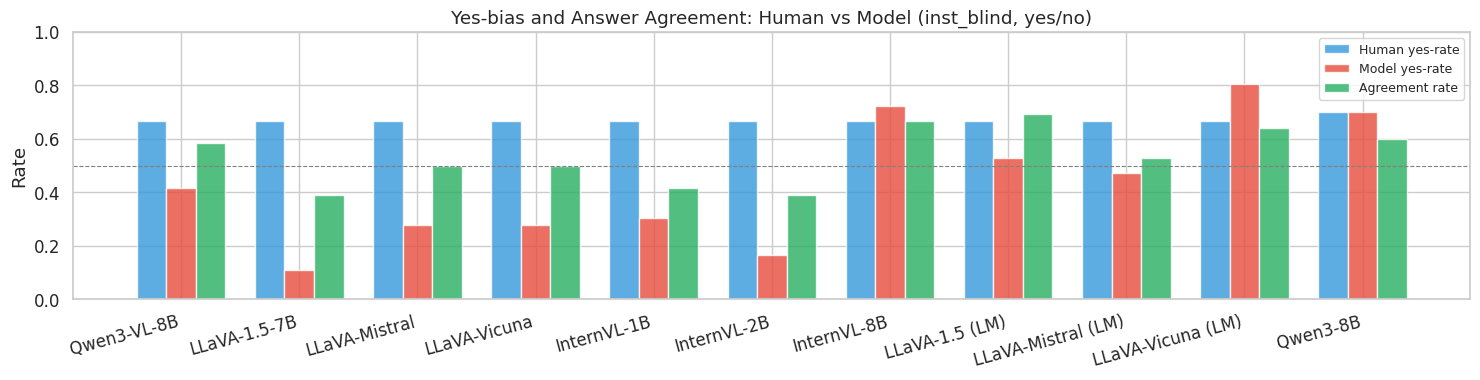

In [56]:
# ── Answer agreement rate: human vs model (yes/no questions, inst_blind) ─────
# Do human and model give the same answer regardless of GT?
# Measures alignment of priors independent of correctness

# Collapse to question level: human majority vote per question
yn_all = df[(df.variant == 'C') & df['question_id'].isin(yn_gt_qids)].copy()
yn_all['answer_yn'] = yn_all['answer_en'].str.lower().str.strip().map(
    lambda x: x if x in ('yes','no') else None)
yn_all = yn_all.dropna(subset=['answer_yn'])
# majority vote: yes if > 50% of participants said yes, else no
yn_q = (yn_all.groupby('question_id')['answer_yn']
        .apply(lambda s: 'yes' if (s == 'yes').mean() > 0.5 else 'no')
        .reset_index().rename(columns={'answer_yn': 'human_maj'}))

agree_rows = []
for label, records in model_calib.items():
    rec_map = {}  # qid → model answer
    path = MODELS[label] / 'vqa_1k_control_inst_blind.jsonl'
    if path.exists():
        for line in open(path):
            ex = json.loads(line)
            qid = int(ex['question_id'])
            if qid not in yn_gt_qids: continue
            raw = ex.get('generated_answers',{}).get('question','')
            raw = _clean_answer(raw)
            ans = re.sub(r'[^\w]', '', raw.strip().lower())
            if ans in ('yes','no'):
                rec_map[qid] = ans

    model_ser = pd.Series(rec_map, name='model_ans').reset_index().rename(columns={'index':'question_id'})
    merged = yn_q.merge(model_ser, on='question_id', how='inner')
    agree = (merged['human_maj'] == merged['model_ans']).mean()
    h_yes  = (merged['human_maj'] == 'yes').mean()
    m_yes  = (merged['model_ans'] == 'yes').mean()
    agree_rows.append({'model': label, 'agreement': agree,
                       'human_yes_rate': h_yes, 'model_yes_rate': m_yes,
                       'n': len(merged)})

agree_df = pd.DataFrame(agree_rows)
print('Answer agreement rate: human vs model (inst_blind, yes/no, variant C)')
print(agree_df.to_string(index=False, float_format='{:.3f}'.format))

# Yes-bias comparison bar chart
fig, ax = plt.subplots(figsize=(15, 4))
x = np.arange(len(agree_df))
w = 0.25
ax.bar(x - w, agree_df['human_yes_rate'],  w, label='Human yes-rate',  color='#3498db', alpha=0.8)
ax.bar(x,     agree_df['model_yes_rate'],  w, label='Model yes-rate',  color='#e74c3c', alpha=0.8)
ax.bar(x + w, agree_df['agreement'],       w, label='Agreement rate',  color='#27ae60', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(agree_df['model'], rotation=15, ha='right')
ax.set_ylabel('Rate'); ax.set_ylim(0, 1)
ax.set_title('Yes-bias and Answer Agreement: Human vs Model (inst_blind, yes/no)')
ax.axhline(0.5, color='gray', ls='--', lw=0.8)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()